# 06 - Tüm Modellerin Karşılaştırılması ve Raporlama

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings, time, joblib, os, sys

from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, roc_auc_score)

sys.path.insert(0, os.path.join('..', 'src'))
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

---
## Bölüm 1: Test Seti ve Modelleri Yükleme

In [2]:
ESA_18_FEATURES = [
    'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
    'duration', 'len', 'gaps_squared', 'len_weighted',
    'var_div_duration', 'var_div_len',
    'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
]
df_full = pd.read_csv('../data/raw/dataset.csv')
test_df = df_full[df_full['train'] == 0].copy()
X_test_raw = test_df[ESA_18_FEATURES].fillna(0).values
y_test = test_df['anomaly'].values

scaler = joblib.load('../models/scaler.joblib')
X_test = scaler.transform(X_test_raw)
print(f"Test seti: {X_test.shape}  (anomali oranı: {y_test.mean():.3f})")

SEQUENCE_MODELS = set()
PYOD_MODELS = {'ECOD', 'COPOD', 'HBOS', 'CBLOF'}

models = {}
joblib_models = [
    ('RandomForest', '../models/rf_model.joblib'), ('XGBoost', '../models/xgb_model.joblib'),
    ('SVM', '../models/svm_model.joblib'), ('LightGBM', '../models/lightgbm_model.joblib'),
    ('CatBoost', '../models/catboost_model.joblib'), ('Stacking Ensemble', '../models/stacking_ensemble_model.joblib'),
    ('ExtraTrees', '../models/extratrees_model.joblib'), ('GradientBoosting', '../models/gradientboosting_model.joblib'),
    ('HistGradientBoosting', '../models/histgradientboosting_model.joblib'), ('AdaBoost', '../models/adaboost_model.joblib'),
    ('KNN', '../models/knn_model.joblib'), ('LogisticRegression', '../models/logisticregression_model.joblib'),
    ('DecisionTree', '../models/decisiontree_model.joblib'), ('NaiveBayes', '../models/naivebayes_model.joblib'),
    ('Voting Ensemble', '../models/voting_ensemble_model.joblib'), ('LDA', '../models/lda_model.joblib'),
    ('QDA', '../models/qda_model.joblib'), ('Bagging', '../models/bagging_model.joblib'),
    ('Ridge', '../models/ridge_model.joblib'), ('SGD', '../models/sgd_model.joblib'),
]
for name, path in joblib_models:
    if os.path.exists(path):
        models[name] = joblib.load(path)

def _kload(path):
    from tensorflow.keras.models import load_model
    return load_model(path, compile=False, safe_mode=False)

try:
    keras_models = [
        ('MLP', '../models/mlp_model.keras'),
    ]
    for name, path in keras_models:
        if os.path.exists(path):
            models[name] = _kload(path)
except Exception as e:
    print(f"Gözetimli Keras modelleri yüklenemedi: {e}")

unsup_dir = '../models/unsupervised/'
for name, fname in [('IsolationForest', 'isolationforest_model.joblib'), ('OneClassSVM', 'oneclasssvm_model.joblib'),
                    ('KMeans', 'kmeans_model.joblib'), ('LOF', 'lof_model.joblib'),
                    ('GMM', 'gmm_model.joblib'), ('EllipticEnvelope', 'ellipticenvelope_model.joblib'),
                    ('PCA', 'pca_model.joblib'), ('DBSCAN', 'dbscan_model.joblib'),
                    ('ECOD', 'ecod_model.joblib'), ('COPOD', 'copod_model.joblib'),
                    ('HBOS', 'hbos_model.joblib'), ('CBLOF', 'cblof_model.joblib')]:
    full = os.path.join(unsup_dir, fname)
    if os.path.exists(full):
        models[name] = joblib.load(full)

try:
    for name, fname in [('Autoencoder', 'autoencoder_model.keras'), ('VAE', 'vae_model.keras')]:
        full = os.path.join(unsup_dir, fname)
        if os.path.exists(full):
            models[name] = _kload(full)
except Exception as e:
    print(f"Gözetimsiz Keras modelleri yüklenemedi: {e}")

thresholds = {}
tp = os.path.join(unsup_dir, 'unsupervised_thresholds.json')
if os.path.exists(tp):
    with open(tp) as f:
        thresholds = json.load(f)

print(f"Yüklenen toplam model sayısı: {len(models)}")
print('   ' + ', '.join(models.keys()))

Test seti: (529, 18)  (anomali oranı: 0.214)
Yüklenen toplam model sayısı: 32
   RandomForest, XGBoost, SVM, LightGBM, CatBoost, Stacking Ensemble, ExtraTrees, GradientBoosting, HistGradientBoosting, AdaBoost, KNN, LogisticRegression, DecisionTree, NaiveBayes, Voting Ensemble, LDA, QDA, Bagging, Ridge, SGD, IsolationForest, OneClassSVM, KMeans, LOF, GMM, EllipticEnvelope, PCA, DBSCAN, ECOD, COPOD, HBOS, CBLOF


---
## Bölüm 2: Tüm Modellerin Metrik Hesaplaması


In [3]:
with open('../reports/metrics/final_comparison.json') as f:
    canonical_metrics = json.load(f)
df_metrics = metrics_table(canonical_metrics, sort_by='AUC_PR')
display(df_metrics.style.background_gradient(cmap='YlGnBu', subset=['AUC_PR', 'F1', 'MCC']).format('{:.4f}'))

predictions = {}
probabilities = {}
inf_times = {}
skipped = []
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

for name, model in models.items():
    try:
        start = time.time()
        if name in SEQUENCE_MODELS:
            prob = model.predict(X_test_seq, verbose=0).flatten()
            pred = (prob >= 0.5).astype(int)
        elif name == 'MLP':
            prob = model.predict(X_test, verbose=0).flatten()
            pred = (prob >= 0.5).astype(int)
        elif name in PYOD_MODELS:
            prob = model.decision_function(X_test)
            pred = model.predict(X_test)
        elif name in ('Autoencoder', 'VAE'):
            recon = model.predict(X_test, verbose=0)
            prob = np.mean(np.power(X_test - recon, 2), axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'PCA':
            recon = model.inverse_transform(model.transform(X_test))
            prob = np.mean(np.power(X_test - recon, 2), axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name in ('IsolationForest', 'LOF'):
            prob = -model.score_samples(X_test)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name in ('GMM', 'EllipticEnvelope'):
            prob = -model.score_samples(X_test)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'OneClassSVM':
            prob = -model.decision_function(X_test)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'KMeans':
            prob = np.min(model.transform(X_test), axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif name == 'DBSCAN':
            prob = model.kneighbors(X_test)[0].min(axis=1)
            pred = (prob > thresholds.get(name, 0)).astype(int)
        elif hasattr(model, 'predict_proba'):
            prob = model.predict_proba(X_test)[:, 1]
            pred = model.predict(X_test)
        elif hasattr(model, 'decision_function'):
            prob = model.decision_function(X_test)
            pred = model.predict(X_test)
        else:
            pred = model.predict(X_test)
            prob = pred.astype(float)

        elapsed_ms = (time.time() - start) * 1000 / len(X_test)
        pred = np.asarray(pred).ravel()
        prob = np.asarray(prob).ravel()
        if len(pred) != len(y_test) or len(prob) != len(y_test):
            raise ValueError("boyut uyumsuz")
        predictions[name] = pred
        probabilities[name] = prob
        inf_times[name] = elapsed_ms
    except Exception:
        skipped.append(name)

if skipped:
    print(f"\nGrafikler için atlanan ve yüklenemeyen model: {len(skipped)} -> {skipped}")

,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR,FAR,FNR
ExtraTrees,0.9716,0.9712,0.8938,0.9309,0.9143,0.9944,0.9829,0.0072,0.1062
Voting Ensemble,0.9679,0.9800,0.8673,0.9202,0.9028,0.9935,0.9800,0.0048,0.1327
MLP,0.9773,0.9633,0.9292,0.9459,0.9318,0.9900,0.9794,0.0096,0.0708
HistGradientBoosting,0.9679,0.9444,0.9027,0.9231,0.9031,0.9901,0.9736,0.0144,0.0973
XGBOD,0.9679,0.9528,0.8938,0.9224,0.9029,0.9911,0.9729,0.0120,0.1062
CatBoost,0.9679,0.9615,0.8850,0.9217,0.9027,0.9899,0.9716,0.0096,0.1150
Stacking Ensemble,0.9509,0.9888,0.7788,0.8713,0.8506,0.9901,0.9707,0.0024,0.2212
RandomForest,0.9641,0.9700,0.8584,0.9108,0.8910,0.9880,0.9673,0.0072,0.1416
LightGBM,0.9622,0.9346,0.8850,0.9091,0.8858,0.9885,0.9672,0.0168,0.1150
XGBoost,0.9660,0.9439,0.8938,0.9182,0.8973,0.9789,0.9625,0.0144,0.1062


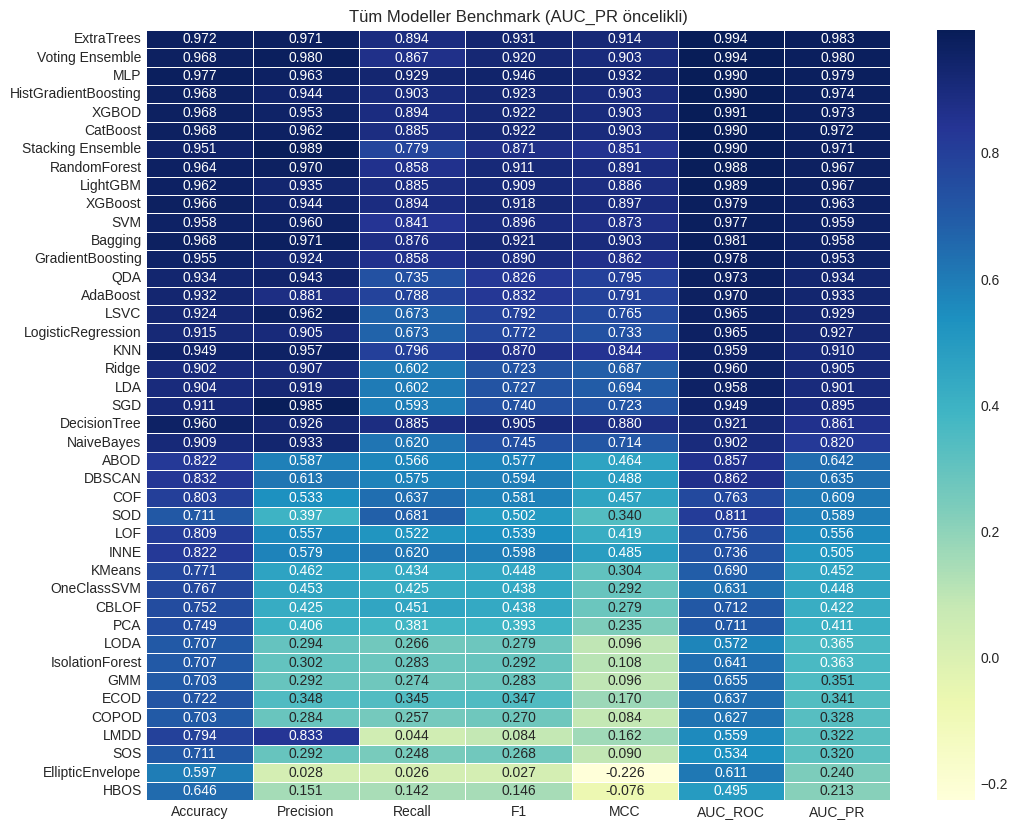

In [4]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_metrics[BENCHMARK_METRICS], annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5)
plt.title('Tüm Modeller Benchmark (AUC_PR öncelikli)')
plt.savefig('../reports/figures/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Derin Sıralı Modeller

In [5]:
with open('../reports/metrics/deep_sequence_comparison.json') as f:
    deep_metrics = json.load(f)
df_deep = metrics_table(deep_metrics, sort_by='AUC_PR')
print(f"Derin sıralı modeller - ham sinyal (segments.csv), resmi Ψ ({len(y_test)} segment), AUC_PR sıralı:")
display(df_deep[BENCHMARK_METRICS].style.background_gradient(cmap='Purples').format('{:.4f}'))

_tab = df_metrics[BENCHMARK_METRICS].copy(); _tab.insert(0, 'Girdi', '18-özellik')
_deep = df_deep[BENCHMARK_METRICS].copy(); _deep.insert(0, 'Girdi', 'ham-sinyal')
df_all = pd.concat([_tab, _deep]).sort_values('AUC_PR', ascending=False)
display(df_all.head(20).style.background_gradient(cmap='YlGnBu', subset=['AUC_PR', 'F1', 'MCC'])
        .format({c: '{:.4f}' for c in BENCHMARK_METRICS}))


Derin sıralı modeller - ham sinyal (segments.csv), resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
CNN1D,0.9187,0.8500,0.7522,0.7981,0.7497,0.9635,0.9105
TCN,0.9168,0.9059,0.6814,0.7778,0.7390,0.9690,0.9096


,Girdi,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
ExtraTrees,18-özellik,0.9716,0.9712,0.8938,0.9309,0.9143,0.9944,0.9829
Voting Ensemble,18-özellik,0.9679,0.9800,0.8673,0.9202,0.9028,0.9935,0.9800
MLP,18-özellik,0.9773,0.9633,0.9292,0.9459,0.9318,0.9900,0.9794
HistGradientBoosting,18-özellik,0.9679,0.9444,0.9027,0.9231,0.9031,0.9901,0.9736
XGBOD,18-özellik,0.9679,0.9528,0.8938,0.9224,0.9029,0.9911,0.9729
CatBoost,18-özellik,0.9679,0.9615,0.8850,0.9217,0.9027,0.9899,0.9716
Stacking Ensemble,18-özellik,0.9509,0.9888,0.7788,0.8713,0.8506,0.9901,0.9707
RandomForest,18-özellik,0.9641,0.9700,0.8584,0.9108,0.8910,0.9880,0.9673
LightGBM,18-özellik,0.9622,0.9346,0.8850,0.9091,0.8858,0.9885,0.9672
XGBoost,18-özellik,0.9660,0.9439,0.8938,0.9182,0.8973,0.9789,0.9625


---
## Bölüm 3: ROC ve PR Eğrileri


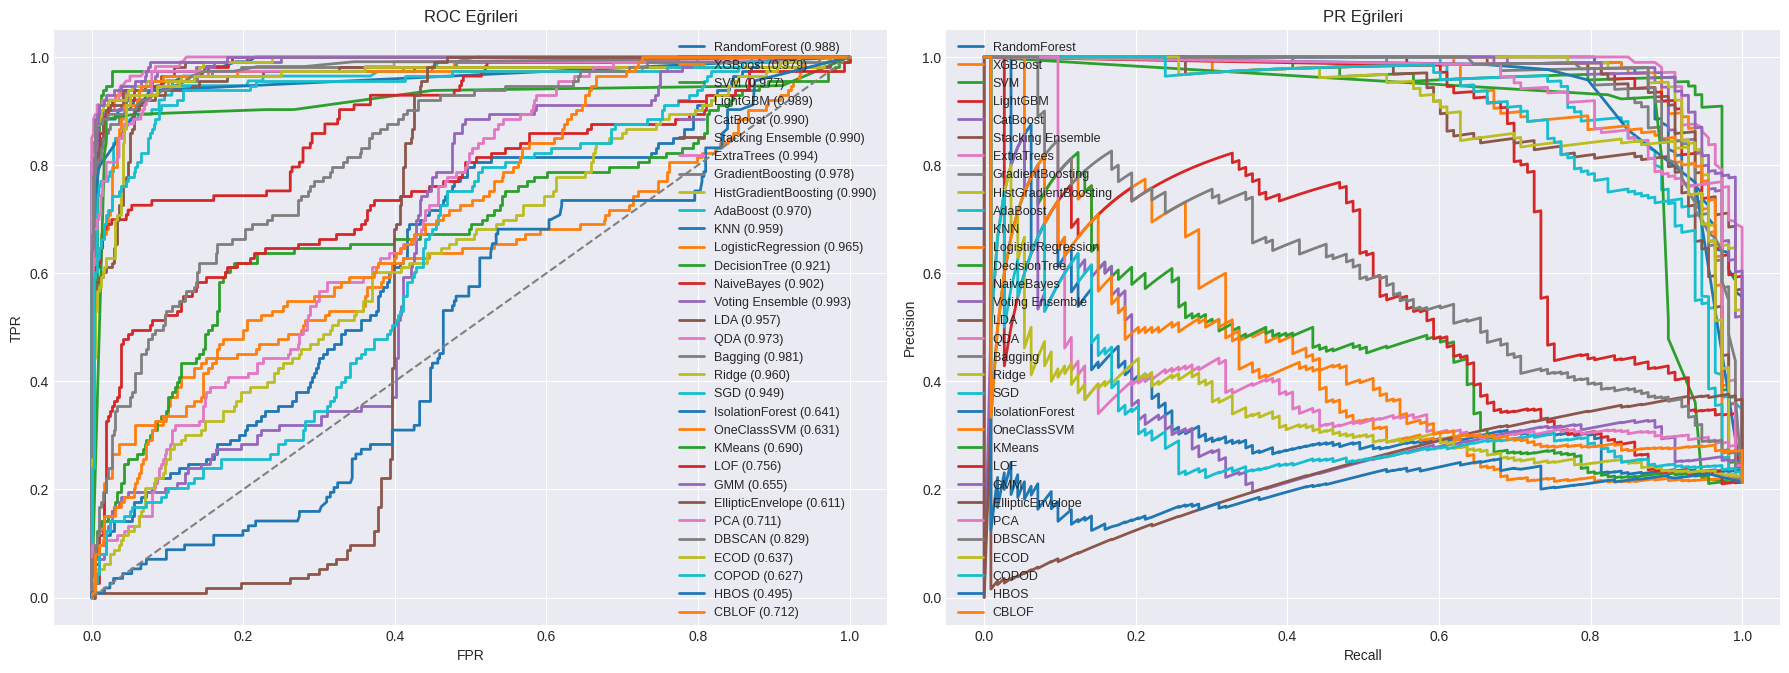

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
for name, prob in probabilities.items():
    try:
        fpr,tpr,_ = roc_curve(y_test, prob); ra = roc_auc_score(y_test, prob)
        ax1.plot(fpr, tpr, lw=2, label=f'{name} ({ra:.3f})')
    except: pass
ax1.plot([0,1],[0,1],color='gray',linestyle='--')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('ROC Eğrileri'); ax1.legend(fontsize=9)

for name, prob in probabilities.items():
    try:
        prec,rec,_ = precision_recall_curve(y_test, prob)
        ax2.plot(rec, prec, lw=2, label=name)
    except: pass
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('PR Eğrileri'); ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Bölüm 4: Confusion Matrix


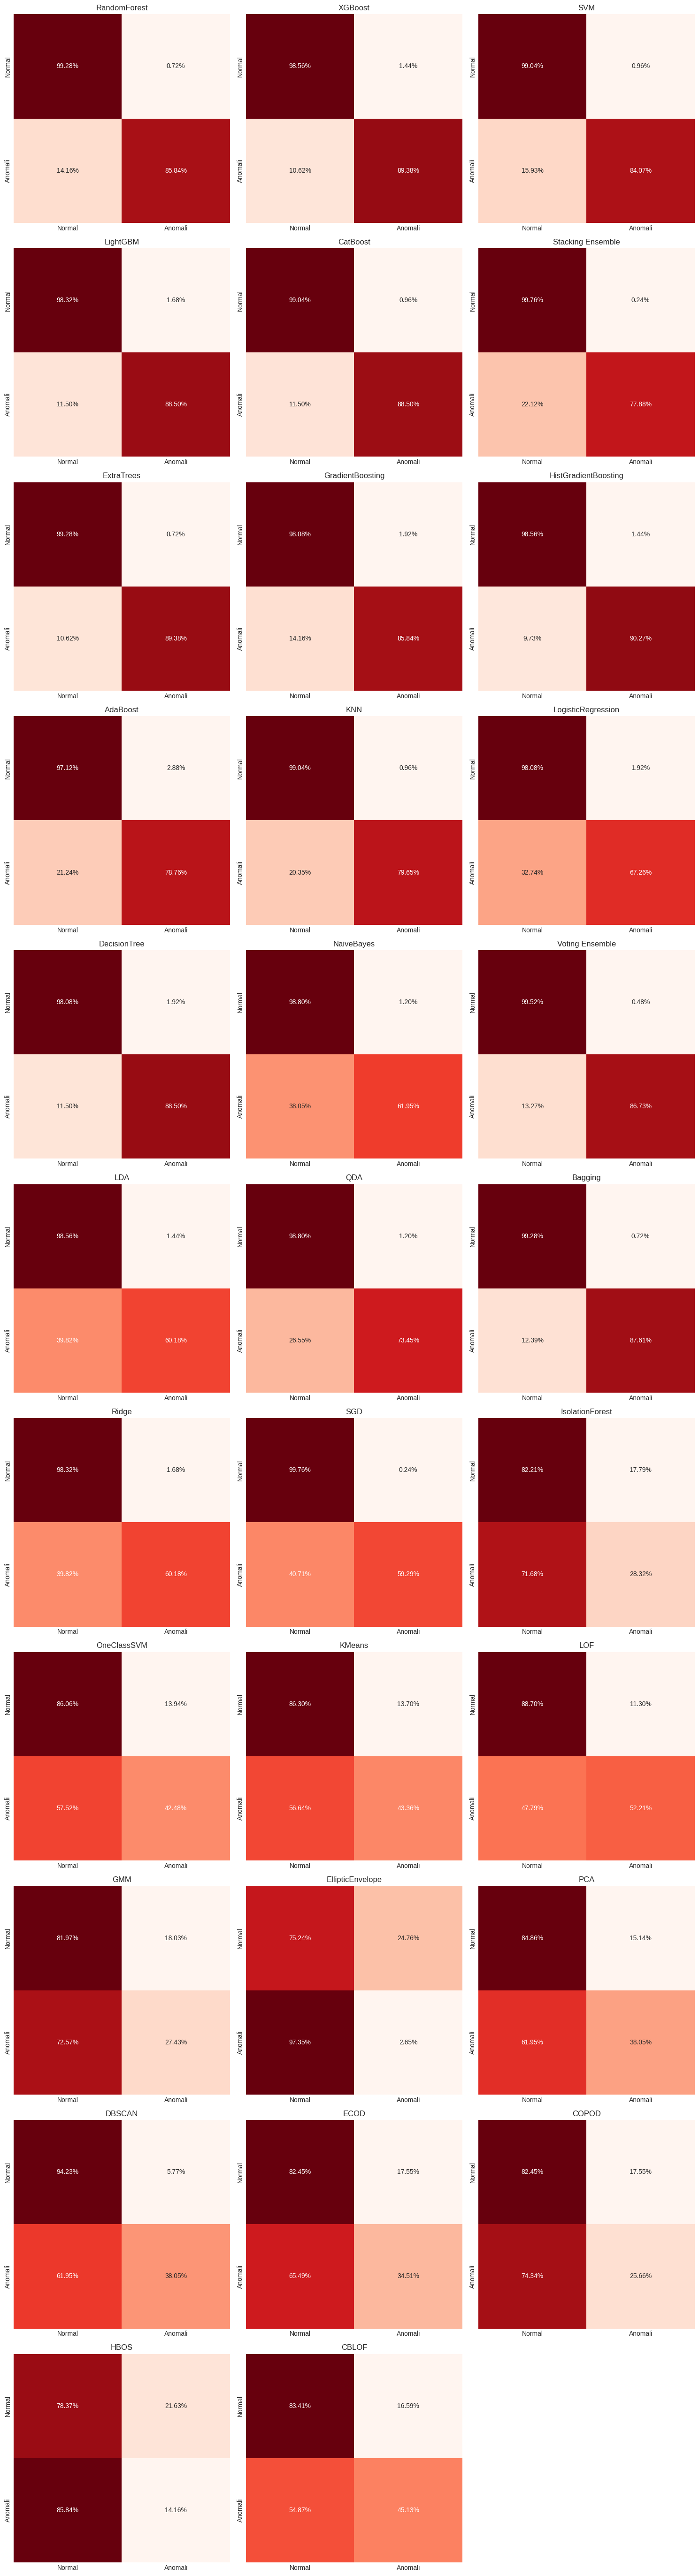

In [7]:
n = len(predictions); cols=3; rows=(n+cols-1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows)); axes = axes.flatten()
for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], cbar=False,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Bölüm 5: Hesaplama Verimliliği


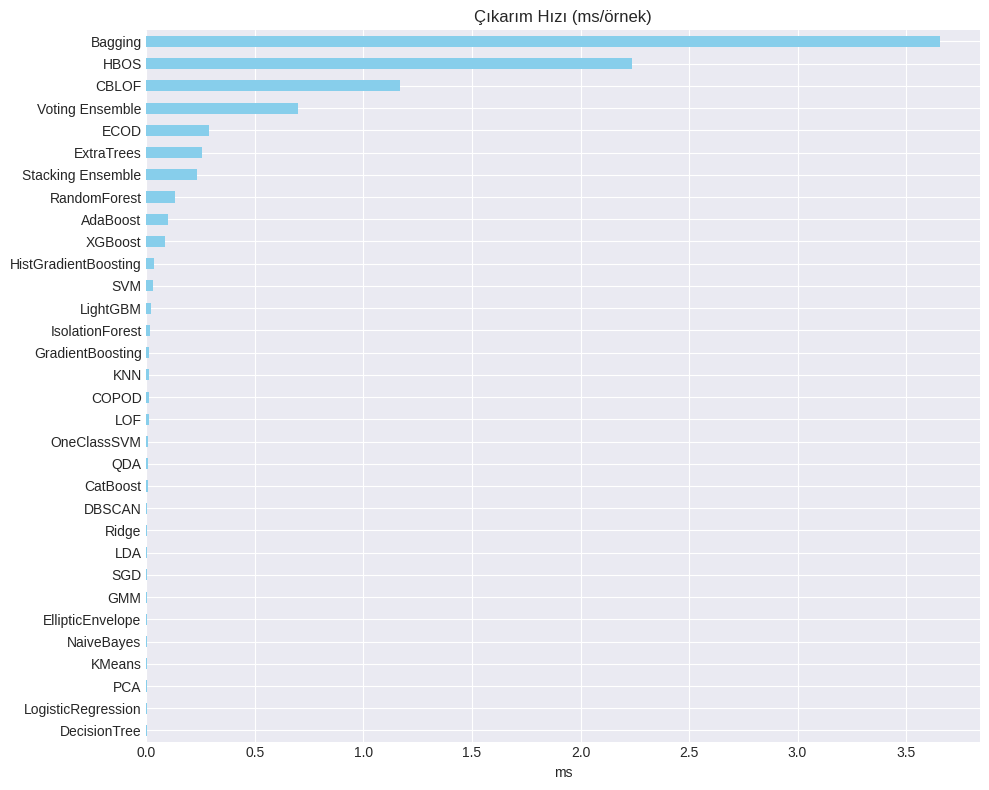

In [8]:
inf_series = pd.Series(inf_times).sort_values()
fig, ax = plt.subplots(figsize=(10, max(6, len(inf_series) * 0.25)))
inf_series.plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Çıkarım Hızı (ms/örnek)')
ax.set_xlabel('ms')
plt.tight_layout()
plt.savefig('../reports/figures/efficiency.png', dpi=300, bbox_inches='tight')
plt.show()